In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown
!pip -q install pylhe

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 4.2 MB/s eta 0:00:00


In [4]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
vlf_files = list(glob.glob('./drive/MyDrive/Distributions/VLF/qq2ttbar_gs4_ydm2/mass_scan/*.npz')) + list(glob.glob('./drive/MyDrive/Distributions/VLF/gg2ttbar_gs4_ydm2/mass_scan/*.npz'))
scalar_files = list(glob.glob('./drive/MyDrive/Distributions//Scalar/qq2ttbar_gs4_ydm2/mass_scan/*.npz')) + list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/mass_scan/*.npz'))
zp_files = list(glob.glob('./drive/MyDrive/Distributions/Zprime/mass_scan/*.npz'))
zp_20pcW_files = list(glob.glob('./drive/MyDrive/Distributions/Zprime/20pc_width/*.npz'))
sm_files = list(glob.glob('./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz'))
fake_data_files = (list(glob.glob('./drive/MyDrive/Distributions/Scalar/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz'))
                    + list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz')))

print("--- File Discovery Check ---")
print(f"VLF files found:       {len(vlf_files)}")
print(f"Scalar files found:    {len(scalar_files)}")
print(f"Zprime files found:    {len(zp_files)}")
print(f"Zprime 20% width files found:    {len(zp_20pcW_files)}")
print(f"Fake data files found: {len(fake_data_files)}")
print(f"SM files found:        {len(sm_files)}\n")

target_xsec = 4.20e-03
lumi = 500.0
sys_err = 0.05
target_yield = target_xsec * lumi * 1000.0

# Bins and Masks
bins = np.arange(500., 4600., 100.)
mass_mask = (bins[:-1] >= 1500) & (bins[:-1] <= 4500)
valid_bin_centers = (bins[:-1] + np.diff(bins)/2)

# ============================================================
# Build Baselines (Fake Data & SM)
# ============================================================
n_fake = np.zeros(len(bins)-1, dtype=np.float64)
fake_w = 0
for f in fake_data_files:
    d = np.load(f, allow_pickle=True)
    h_fake, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    n_fake += h_fake * lumi * 1000.0
    fake_w += np.sum(h_fake[mass_mask])

# Normalize fake data inside the mass mask to match the target yield
factor = target_yield / np.sum(n_fake[mass_mask])
n_fake = n_fake * factor

target_fake_yield = np.sum(n_fake[mass_mask], dtype=np.float64)
print(f"Fake Data correctly normalized to yield: {target_fake_yield:.2f} events in target window.")

n_sm = np.zeros(len(bins)-1, dtype=np.float64)
for f in sm_files:
    d = np.load(f, allow_pickle=True)
    h_sm, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    n_sm += h_sm * lumi * 1000.0
n_sm = n_sm / len(sm_files)

# Pre-calculate the variance denominator for the chi2
chi2_denom_full = (n_fake + n_sm) + (sys_err * n_sm)**2
chi2_denom_masked = chi2_denom_full

# ============================================================
# Prepare Global Trackers
# ============================================================
# Dedicated keys are required for each model variation to prevent overwriting
results = {
    'VLF': {'masses': [], 'chi2': [], 'mu': []},
    'Scalar': {'masses': [], 'chi2': [], 'mu': []},
    'Zprime': {'masses': [], 'chi2': [], 'mu': []},
    'Zprime_20pc': {'masses': [], 'chi2': [], 'mu': []}
}

# Trackers for the absolute global minimums: (Mass, minimum_chi2, best_mu)
chi2_min = {
    'VLF': (None, np.inf, 0.),
    'Scalar': (None, np.inf, 0.),
    'Zprime': (None, np.inf, 0.),
    'Zprime_20pc': (None, np.inf, 0.),
    'FakeData': (1000.0, 0.0, np.sqrt(factor))
}

history = {
    'bin_centers': valid_bin_centers,
    'denominator': chi2_denom_masked,
    'VLF': {}, 'Scalar': {}, 'Zprime': {}, 'Zprime_20pc': {},
    'scale_factors': {'VLF': {}, 'Scalar': {}, 'Zprime': {}, 'Zprime_20pc': {}}
}

# Helper function to find the optimal scaling (mu) for a given mass template
def find_best_mu(n_sig_template, n_fake_data, denom):
    # Objective function: minimize chi^2 with respect to a single scaling parameter `mu`
    def objective(mu):
        return np.sum(((mu * n_sig_template - n_fake_data)**2) / denom, dtype=np.float64)

    # x0 is the initial guess. bounds=(0, None) ensures signal strength cannot go negative.
    res = minimize(objective, x0=[1.0], bounds=[(0.0, None)])
    best_mu = res.x[0]
    best_chi2 = res.fun
    return best_mu, best_chi2

# ============================================================
# Mass Scan (VLF)
# ============================================================
masses_vlf_scalar = np.arange(1000., 3100., 100.)

for m in masses_vlf_scalar:
    vlf_scan = glob.glob(f'./drive/MyDrive/Distributions/VLF/*/mass_scan/mPsiT_{m:.0f}_mSDM_{(m-100.):.0f}.npz')
    n_vlf = np.zeros(len(bins)-1, dtype=np.float64)

    for f in vlf_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_vlf += h * lumi * 1000.0

    if np.sum(n_vlf) == 0: continue

    # Find optimal signal strength (interpreting mu as yDM^4 cross-section scaling)
    best_mu, chi2_val = find_best_mu(n_vlf, n_fake, chi2_denom_masked)

    # If using yDM parametrization: best_mu = yDM^2, so yDM = sqrt(best_mu)
    yDM_val = np.sqrt(best_mu, dtype=np.float64)

    # Filter out unphysical couplings
    if yDM_val >= 10.0:
        continue

    num_vlf = ((best_mu * n_vlf - n_fake)**2)
    history['VLF'][m] = num_vlf
    history['scale_factors']['VLF'][m] = best_mu

    results['VLF']['masses'].append(m)
    results['VLF']['chi2'].append(chi2_val)
    results['VLF']['mu'].append(best_mu)

    if chi2_val < chi2_min['VLF'][1]:
        chi2_min['VLF'] = (m, chi2_val, np.sqrt(best_mu))

# ============================================================
# Mass Scan (Scalar)
# ============================================================
for m in masses_vlf_scalar:
    scalar_scan = glob.glob(f'./drive/MyDrive/Distributions/Scalar/*/mass_scan/mPsiT_{m:.0f}_mSDM_{(m-100.):.0f}.npz')
    n_scalar = np.zeros(len(bins)-1, dtype=np.float64)

    for f in scalar_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_scalar += h * lumi * 1000.0

    if np.sum(n_scalar) == 0: continue

    best_mu, chi2_val = find_best_mu(n_scalar, n_fake, chi2_denom_masked)
    yDM_val = np.sqrt(best_mu, dtype=np.float64)

    if yDM_val >= 10.1:
        continue

    num_scalar = ((best_mu * n_scalar - n_fake)**2)
    history['Scalar'][m] = num_scalar
    history['scale_factors']['Scalar'][m] = best_mu

    results['Scalar']['masses'].append(m)
    results['Scalar']['chi2'].append(chi2_val)
    results['Scalar']['mu'].append(best_mu)

    if chi2_val < chi2_min['Scalar'][1]:
        chi2_min['Scalar'] = (m, chi2_val, np.sqrt(best_mu))

# ============================================================
# Mass Scan (Zprime - 1% Width)
# ============================================================
masses_zp = np.arange(1000., 4600., 100.)

for m in masses_zp:
    zp_scan = glob.glob(f'./drive/MyDrive/Distributions/Zprime/mass_scan/mZp_{m:.0f}.npz')
    n_Zp = np.zeros(len(bins)-1, dtype=np.float64)

    for f in zp_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_Zp += h * lumi * 1000.0

    if np.sum(n_Zp) == 0: continue

    best_mu, chi2_val = find_best_mu(n_Zp, n_fake, chi2_denom_masked)

    num_zp = ((best_mu * n_Zp - n_fake)**2)
    history['Zprime'][m] = num_zp
    history['scale_factors']['Zprime'][m] = best_mu

    results['Zprime']['masses'].append(m)
    results['Zprime']['chi2'].append(chi2_val)
    results['Zprime']['mu'].append(best_mu)

    if chi2_val < chi2_min['Zprime'][1]:
        chi2_min['Zprime'] = (m, chi2_val, np.sqrt(best_mu))

# ============================================================
# Mass Scan (Zprime - 20% Width)
# ============================================================
for m in masses_zp:
    zp_scan = glob.glob(f'./drive/MyDrive/Distributions/Zprime/20pc_width/mZp_{m:.0f}.npz')
    n_Zp = np.zeros(len(bins)-1, dtype=np.float64)

    for f in zp_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_Zp += h * lumi * 1000.0

    if np.sum(n_Zp) == 0: continue

    best_mu, chi2_val = find_best_mu(n_Zp, n_fake, chi2_denom_masked)

    num_zp = ((best_mu * n_Zp - n_fake)**2)
    history['Zprime_20pc'][m] = num_zp
    history['scale_factors']['Zprime_20pc'][m] = best_mu

    results['Zprime_20pc']['masses'].append(m)
    results['Zprime_20pc']['chi2'].append(chi2_val)
    results['Zprime_20pc']['mu'].append(best_mu)

    if chi2_val < chi2_min['Zprime_20pc'][1]:
        chi2_min['Zprime_20pc'] = (m, chi2_val, np.sqrt(best_mu))
    if m == 2600:
      print(best_mu * sum(d['weights']))
# ============================================================
# Output 2D Global Minimums
# ============================================================
print("\n--- Global Best Fit Results (Mass, Signal Strength) ---")
for model, fit in chi2_min.items():
    mass, chi2, best_mu = fit
    if mass is not None:
        print(f"{model:12}: Mass = {mass:.0f} GeV | Scaling factor (yDM) = {best_mu:.6e} | Minimum Chi^2 = {chi2:.2f}")

--- File Discovery Check ---
VLF files found:       43
Scalar files found:    46
Zprime files found:    41
Zprime 20% width files found:    41
Fake data files found: 2
SM files found:        8

Fake Data correctly normalized to yield: 2100.00 events in target window.
0.0015053448852659498

--- Global Best Fit Results (Mass, Signal Strength) ---
VLF         : Mass = 1400 GeV | Scaling factor (yDM) = 2.715766e+00 | Minimum Chi^2 = 0.07
Scalar      : Mass = 1000 GeV | Scaling factor (yDM) = 4.430268e+00 | Minimum Chi^2 = 0.00
Zprime      : Mass = 2800 GeV | Scaling factor (yDM) = 1.807331e-01 | Minimum Chi^2 = 0.43
Zprime_20pc : Mass = 2600 GeV | Scaling factor (yDM) = 2.574416e+00 | Minimum Chi^2 = 0.13
FakeData    : Mass = 1000 GeV | Scaling factor (yDM) = 4.429246e+00 | Minimum Chi^2 = 0.00


In [5]:
# ------------------------------------------------------------
# Automated Configuration (Using Best Fits)
# ------------------------------------------------------------
best_fits = {
    'VLF':    {'mPsiT': chi2_min['VLF'][0], 'mSDM': chi2_min['VLF'][0]- 100., 'scale_factor': chi2_min['VLF'][2]},
    'Scalar': {'mST': chi2_min['Scalar'][0], 'mChi': chi2_min['Scalar'][0]-100., 'scale_factor': chi2_min['Scalar'][2]},
    'Zprime': {'mZp': chi2_min['Zprime'][0], 'scale_factor': chi2_min['Zprime'][2]},
    'Zprime_20pc': {'mZp': chi2_min['Zprime_20pc'][0], 'scale_factor': chi2_min['Zprime_20pc'][2]},
    'FakeData': {'scale_factor': chi2_min['FakeData'][2]}
}

vlf_files = (
    list(glob.glob(f'./drive/MyDrive/Distributions/VLF/qq2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["VLF"]["mPsiT"]:.0f}_mSDM_{best_fits["VLF"]["mSDM"]:.0f}.npz')) +
    list(glob.glob(f'./drive/MyDrive/Distributions/VLF/gg2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["VLF"]["mPsiT"]:.0f}_mSDM_{best_fits["VLF"]["mSDM"]:.0f}.npz'))
)

scalar_files = (
    list(glob.glob(f'./drive/MyDrive/Distributions/Scalar/qq2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["Scalar"]["mST"]:.0f}_mSDM_{best_fits["Scalar"]["mChi"]:.0f}.npz')) +
    list(glob.glob(f'./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["Scalar"]["mST"]:.0f}_mSDM_{best_fits["Scalar"]["mChi"]:.0f}.npz'))
)

zp_files = list(glob.glob(f'./drive/MyDrive/Distributions/Zprime/mass_scan/mZp_{best_fits["Zprime"]["mZp"]:.0f}.npz'))
zp_20pc_files = list(glob.glob(f'./drive/MyDrive/Distributions/Zprime/20pc_width/mZp_{best_fits["Zprime_20pc"]["mZp"]:.0f}.npz'))

print("\n--- Model Assembly Check ---")
print(f"VLF files loaded:         {len(vlf_files)}")
print(f"Scalar files loaded:      {len(scalar_files)}")
print(f"Zprime files loaded:      {len(zp_files)}")
print(f"Zprime_20pc files loaded: {len(zp_20pc_files)}")

# ------------------------------------------------------------
# Memory-Optimized Extraction Setup
# ------------------------------------------------------------
KEYS_TO_SUM = ['xsec (pb)', 'n_events']
KEYS_TO_KEEP = ['mTT', 'weights', 'pT']

raw_data = {
    'FakeData':    {'arrays': {}, 'scalars': {}},
    'Scalar':      {'arrays': {}, 'scalars': {}},
    'VLF':         {'arrays': {}, 'scalars': {}},
    'Zprime':      {'arrays': {}, 'scalars': {}},
    'Zprime_20pc': {'arrays': {}, 'scalars': {}},
    'SM':          {'arrays': {}, 'scalars': {}}
}

# ------------------------------------------------------------
# Data Loading Loop
# ------------------------------------------------------------
for f in vlf_files + scalar_files + zp_files + zp_20pc_files + sm_files + fake_data_files:
    aux = np.load(f, allow_pickle=True)

    model_name = aux['model']
    if isinstance(model_name, np.ndarray):
        model_name = model_name.item() if model_name.size == 1 else model_name[0]
    if isinstance(model_name, bytes):
        model_name = model_name.decode('utf-8')

    targets = []

    if f in fake_data_files:
        targets.append(raw_data['FakeData'])

    if model_name == '1-loop VLF' and f in vlf_files:
        targets.append(raw_data['VLF'])
    elif model_name == '1-loop Scalar' and f in scalar_files:
        targets.append(raw_data['Scalar'])
    elif model_name == 'Z prime' and f in zp_files:
        targets.append(raw_data['Zprime'])
    elif model_name == 'Z prime' and f in zp_20pc_files:
        targets.append(raw_data['Zprime_20pc'])
    elif model_name == 'SM' and f in sm_files:
        targets.append(raw_data['SM'])

    if not targets:
        aux.close()
        continue

    for target in targets:
        for key in aux.files:
            val = aux[key]
            if key in KEYS_TO_SUM:
                if key not in target['scalars']: target['scalars'][key] = 0.0
                target['scalars'][key] += float(val.item())
            elif val.ndim == 0 or val.size == 1:
                if not isinstance(val.item(), dict):
                    target['scalars'][key] = val.item()
            else:
                if key not in KEYS_TO_KEEP: continue
                if key not in target['arrays']: target['arrays'][key] = []
                target['arrays'][key].append(val[:])

    aux.close()

# Concatenate arrays
for model in raw_data:
    for key, list_of_arrays in raw_data[model]['arrays'].items():
        if list_of_arrays:
            raw_data[model]['arrays'][key] = np.concatenate(list_of_arrays, axis=0)

# ------------------------------------------------------------
# Post-Processing: Weights & Explicit High-Precision Normalization
# ------------------------------------------------------------
sm_file_count = len(sm_files)
if sm_file_count > 0 and 'weights' in raw_data['SM']['arrays']:
    raw_data['SM']['arrays']['weights'] = raw_data['SM']['arrays']['weights'].astype(np.float64) / sm_file_count

for model_name, data in raw_data.items():
    arrs = data['arrays']
    if not arrs: continue

    if 'weights' in arrs:
        arrs['weights'] = arrs['weights'].astype(np.float64)

    if model_name == 'FakeData' and 'weights' in arrs:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        arrs['weights'] = arrs['weights'] * factor_sq
        print(f"[FakeData] Explicitly Scaled by {factor:.6e} to hit target.")

    elif model_name in ['VLF', 'Scalar', 'Zprime', 'Zprime_20pc']:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        if factor_sq != 1.0 and 'weights' in arrs:
            arrs['weights'] = arrs['weights'] * factor_sq
            print(f"[{model_name:11}] Scaled by Best-Fit factor: {factor:.6e}")

    if 'weights' in arrs: arrs['weight'] = arrs.pop('weights')
    if 'mTT' in arrs:     arrs['m_tt'] = arrs.pop('mTT')

# ------------------------------------------------------------
# Pure NumPy Assembly into DataFrames
# ------------------------------------------------------------
l_fake = len(raw_data['FakeData']['arrays'].get('weight', []))
l_s    = len(raw_data['Scalar']['arrays'].get('weight', []))
l_v    = len(raw_data['VLF']['arrays'].get('weight', []))
l_z    = len(raw_data['Zprime']['arrays'].get('weight', []))
l_z20  = len(raw_data['Zprime_20pc']['arrays'].get('weight', []))

final_dict = {}
labels_list = []
if l_fake > 0: labels_list.append(np.full(l_fake, 'FakeData'))
if l_s > 0:    labels_list.append(np.full(l_s, 'Scalar'))
if l_v > 0:    labels_list.append(np.full(l_v, 'VLF'))
if l_z > 0:    labels_list.append(np.full(l_z, 'Zprime'))
if l_z20 > 0:  labels_list.append(np.full(l_z20, 'Zprime_20pc'))

if labels_list:
    final_dict['label'] = np.concatenate(labels_list)

keys_to_stack = list(raw_data['SM']['arrays'].keys())

for key in keys_to_stack:
    arrs_to_concat = []
    if l_fake > 0 and key in raw_data['FakeData']['arrays']:    arrs_to_concat.append(raw_data['FakeData']['arrays'][key])
    if l_s > 0 and key in raw_data['Scalar']['arrays']:         arrs_to_concat.append(raw_data['Scalar']['arrays'][key])
    if l_v > 0 and key in raw_data['VLF']['arrays']:            arrs_to_concat.append(raw_data['VLF']['arrays'][key])
    if l_z > 0 and key in raw_data['Zprime']['arrays']:         arrs_to_concat.append(raw_data['Zprime']['arrays'][key])
    if l_z20 > 0 and key in raw_data['Zprime_20pc']['arrays']:  arrs_to_concat.append(raw_data['Zprime_20pc']['arrays'][key])

    if arrs_to_concat:
        final_dict[key] = np.concatenate(arrs_to_concat, axis=0)

df_bsm = pd.DataFrame(final_dict)

df_sm = pd.DataFrame(raw_data['SM']['arrays'])
if not df_sm.empty:
    df_sm['label'] = 'SM'

del raw_data, final_dict, labels_list
gc.collect()

print("\n--- DataFrame Assembly Complete ---")
print(f"BSM Events: {len(df_bsm)}")
print(f"SM Events:  {len(df_sm)}")


--- Model Assembly Check ---
VLF files loaded:         2
Scalar files loaded:      2
Zprime files loaded:      1
Zprime_20pc files loaded: 1
[FakeData] Explicitly Scaled by 4.429246e+00 to hit target.
[Scalar     ] Scaled by Best-Fit factor: 4.430268e+00
[VLF        ] Scaled by Best-Fit factor: 2.715766e+00
[Zprime     ] Scaled by Best-Fit factor: 1.807331e-01
[Zprime_20pc] Scaled by Best-Fit factor: 2.574416e+00

--- DataFrame Assembly Complete ---
BSM Events: 6906068
SM Events:  6600000


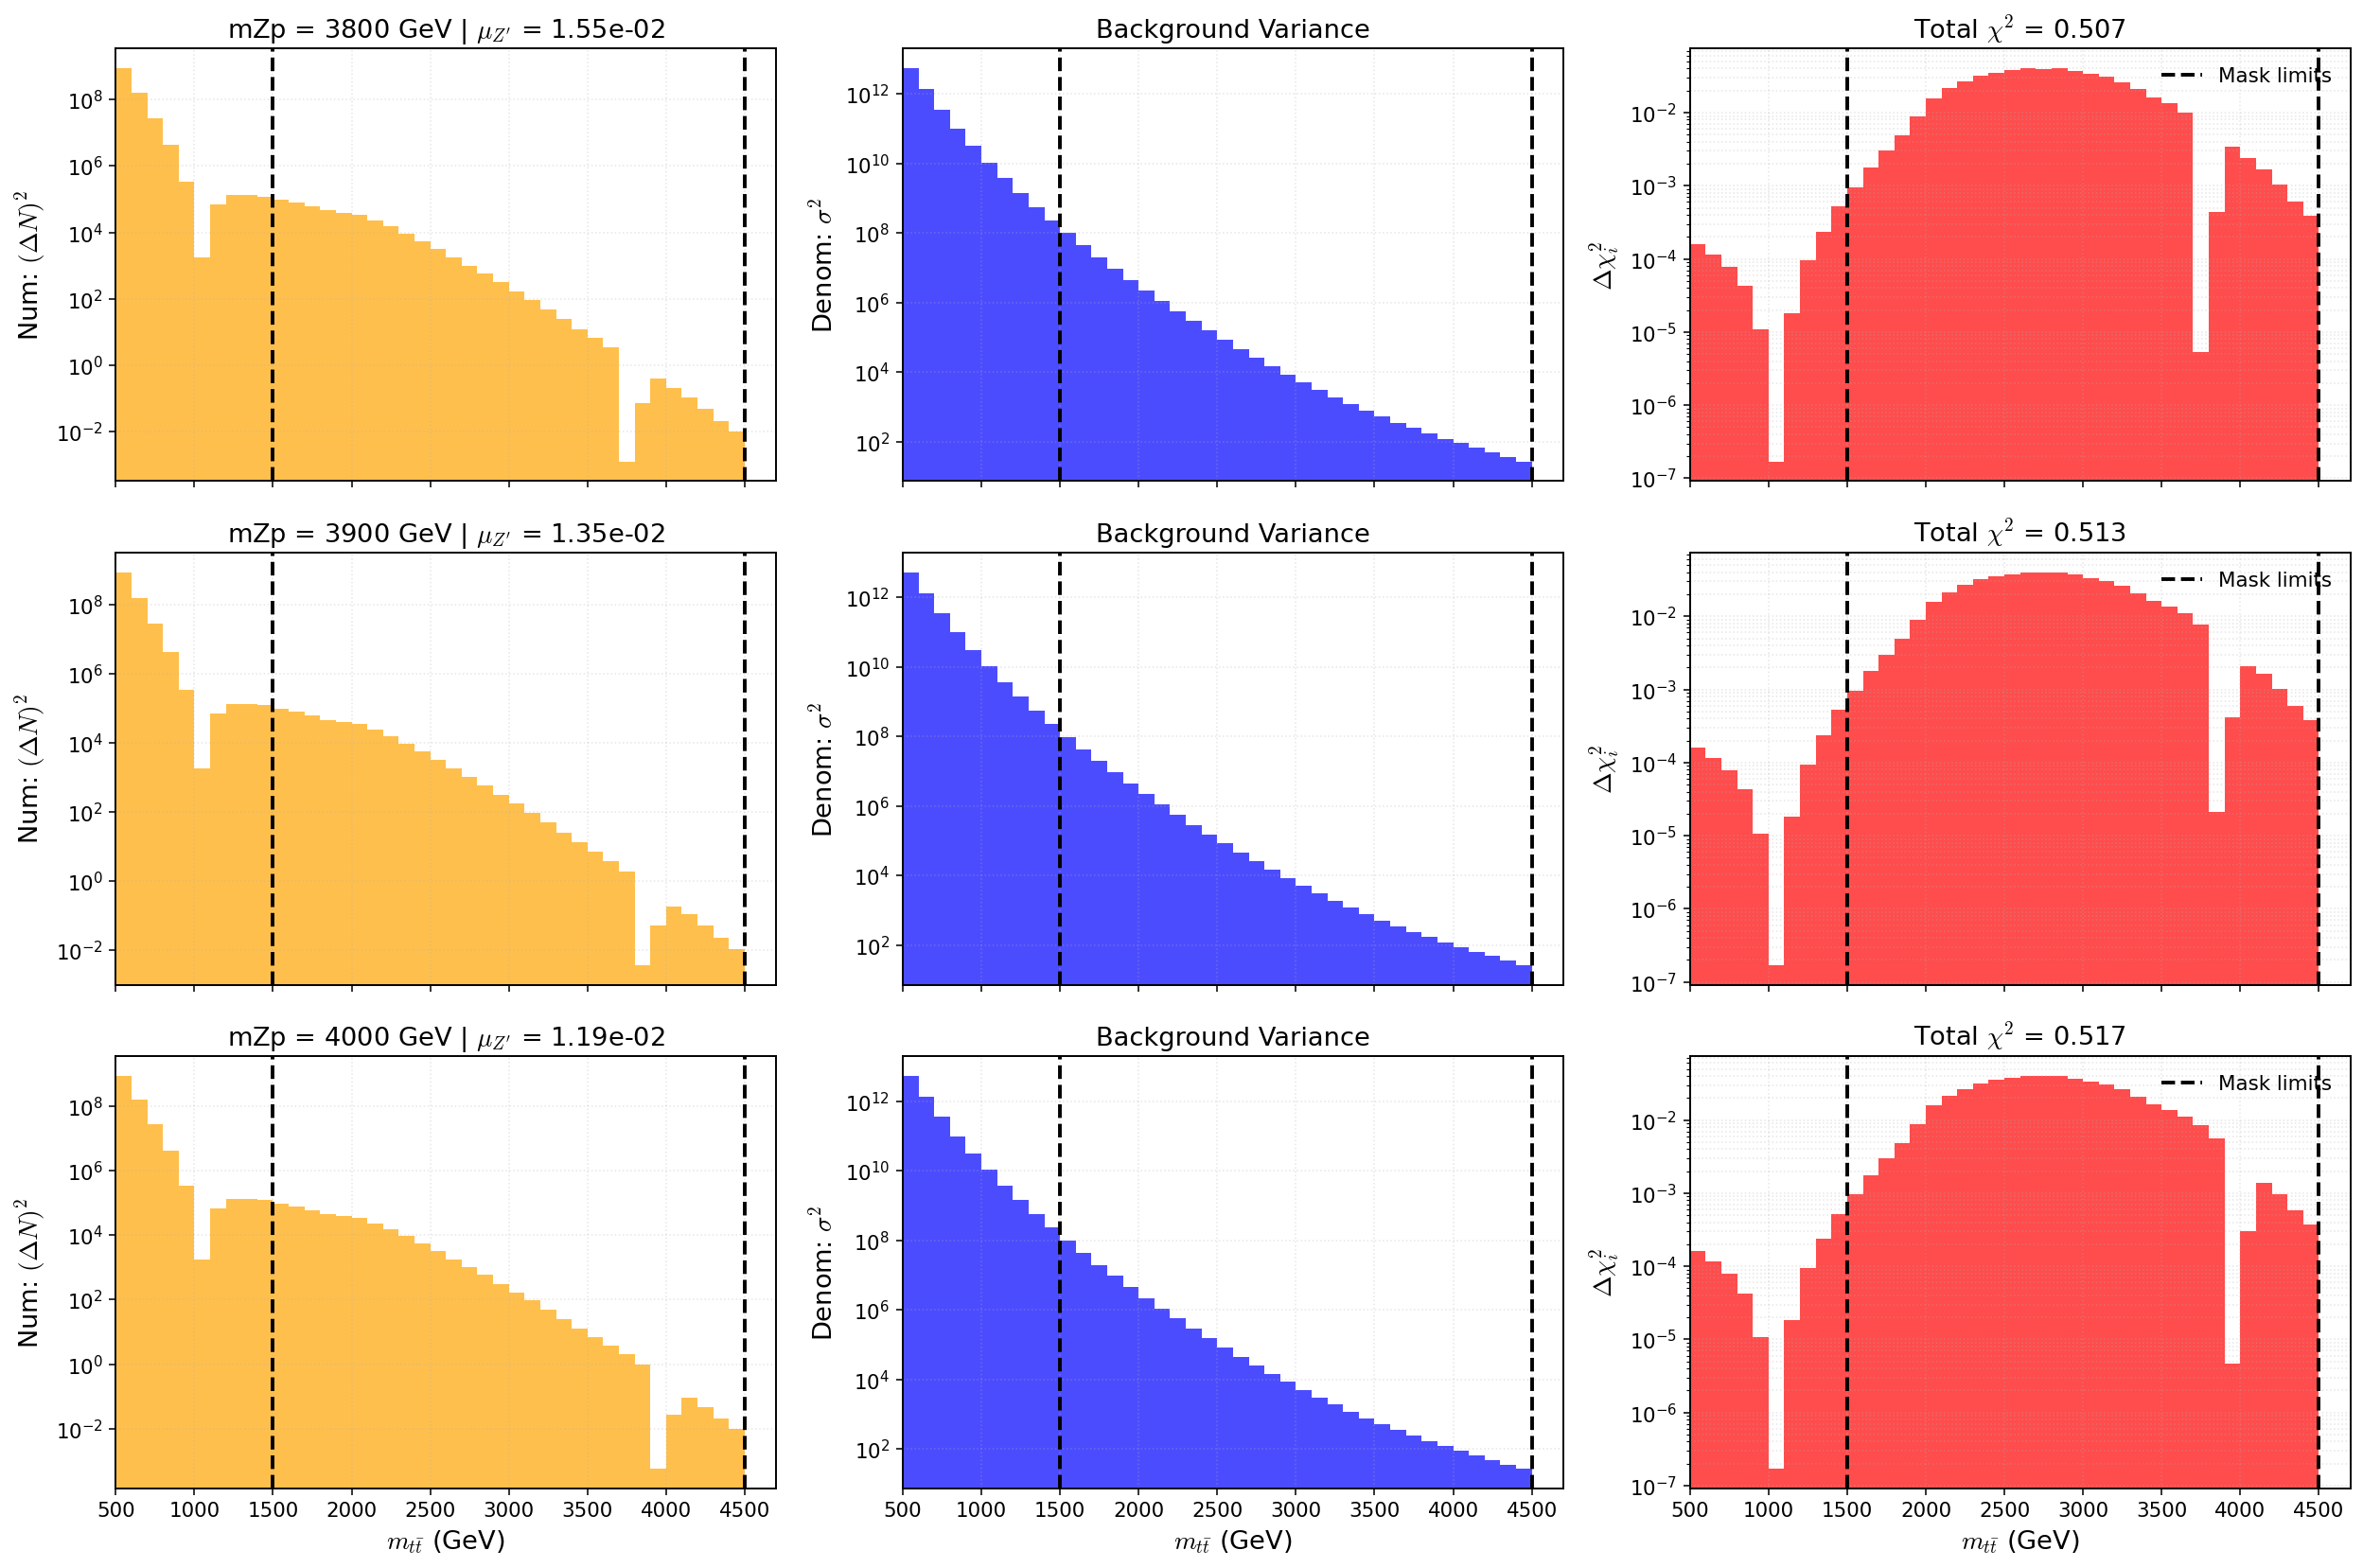

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Bin-by-Bin Chi^2 Diagnostic Plot (Decomposed)
# ------------------------------------------------------------
debug_masses = [3800.0, 3900.0, 4000.0] # Sorted for a logical progression

# Create a grid: Rows = Masses, Columns = [Numerator, Denominator, Chi^2]
fig, axes = plt.subplots(len(debug_masses), 3, figsize=(18, 4 * len(debug_masses)), sharex=True)

# Ensure axes is always a 2D array even if there is only 1 mass
if len(debug_masses) == 1:
    axes = np.atleast_2d(axes)

# Extract the shared denominator and x-axis from history
# To plot bars aligned by edge like the original code, we calculate the left edges (centers - 50 GeV)
x_edges = history['bin_centers'] - 50.0
denominator = history['denominator']

for i, m in enumerate(debug_masses):
    # Map axes for this specific row
    ax_num = axes[i, 0]
    ax_den = axes[i, 1]
    ax_chi = axes[i, 2]

    # Safety check
    if m not in history['Zprime']:
        print(f"Warning: Mass {m} not found in history['Zprime']. Skipping.")
        continue

    # Extract the pre-calculated numerator and scale factor directly from history
    numerator = history['Zprime'][m]

    # Retrieve the mu_Zp scaling factor for this specific mass
    mu_Zp = history['scale_factors']['Zprime'][m]

    # Calculate chi2 bins dynamically
    chi2_bins = numerator / denominator
    total_chi2 = np.sum(chi2_bins)

    # 1. Plot Numerator (Now with mu_Zp in the title)
    ax_num.bar(x_edges, numerator, width=100, align='edge', color='orange', alpha=0.7)
    ax_num.set_ylabel(r"Num: $(\Delta N)^2$")
    ax_num.set_yscale('log')
    ax_num.set_title(f"mZp = {m:.0f} GeV | $\mu_{{Z^\prime}}$ = {mu_Zp:.2e}")

    # 2. Plot Denominator
    ax_den.bar(x_edges, denominator, width=100, align='edge', color='blue', alpha=0.7)
    ax_den.set_ylabel(r"Denom: $\sigma^2$")
    ax_den.set_yscale('log')
    ax_den.set_title(f"Background Variance")

    # 3. Plot Chi^2 Contribution
    ax_chi.bar(x_edges, chi2_bins, width=100, align='edge', color='red', alpha=0.7)
    ax_chi.set_ylabel(r"$\Delta \chi^2_i$")
    ax_chi.set_yscale('log')
    ax_chi.set_title(f"Total $\chi^2$ = {total_chi2:.3f}")

    # Apply standard formatting across all three columns
    for ax in [ax_num, ax_den, ax_chi]:
        # Draw the mask limits
        ax.axvline(1500, color='black', linestyle='--', lw=2, label='Mask limits' if ax == ax_chi else "")
        ax.axvline(4500, color='black', linestyle='--', lw=2)
        ax.grid(True, alpha=0.3, which='both', linestyle=':')

        # Add a little padding to the x-axis so the mask lines are clearly visible
        ax.set_xlim(500, 4700)

        if ax == ax_chi:
            ax.legend(loc='upper right')

# Add X-axis labels only to the bottom row
for j in range(3):
    axes[-1, j].set_xlabel(r"$m_{t\bar{t}}$ (GeV)", fontsize=14)

plt.tight_layout()
plt.show()

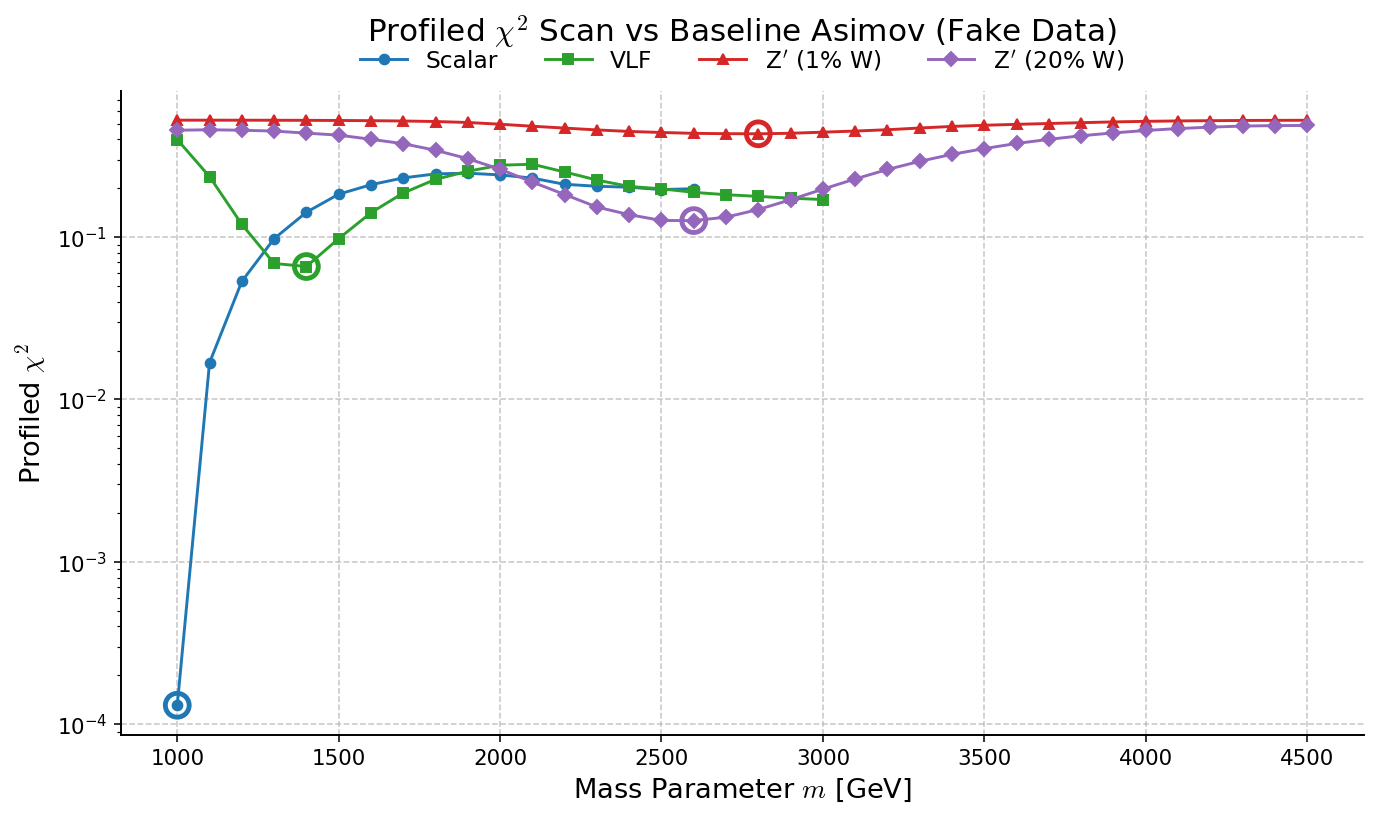

In [ ]:


# ============================================================
# Plotting the Profiled Chi^2 Mass Scan
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the Chi^2 curves using the updated dictionary structure
ax.plot(results['Scalar']['masses'], results['Scalar']['chi2'], label='Scalar', color='#1f77b4', marker='o', linestyle='-', linewidth=1.5, markersize=5)
ax.plot(results['VLF']['masses'], results['VLF']['chi2'], label='VLF', color='#2ca02c', marker='s', linestyle='-', linewidth=1.5, markersize=5)
ax.plot(results['Zprime']['masses'], results['Zprime']['chi2'], label=r'Z$^\prime$ (1% W)', color='#d62728', marker='^', linestyle='-', linewidth=1.5, markersize=5)

# Add the Z' with 20% width
ax.plot(results['Zprime_20pc']['masses'], results['Zprime_20pc']['chi2'], label=r'Z$^\prime$ (20% W)', color='#9467bd', marker='D', linestyle='-', linewidth=1.5, markersize=5)

# Highlight the Minimums (Best Fits)
# chi2_min stores tuples of: (mass, minimum_chi2, best_mu)
ax.scatter(chi2_min['Scalar'][0], chi2_min['Scalar'][1], s=150, facecolors='none', edgecolors='#1f77b4', linewidths=2.5, zorder=5)
ax.scatter(chi2_min['VLF'][0], chi2_min['VLF'][1], s=150, facecolors='none', edgecolors='#2ca02c', linewidths=2.5, zorder=5)
ax.scatter(chi2_min['Zprime'][0], chi2_min['Zprime'][1], s=150, facecolors='none', edgecolors='#d62728', linewidths=2.5, zorder=5)

# Add highlight for Z' 20% width minimum
ax.scatter(chi2_min['Zprime_20pc'][0], chi2_min['Zprime_20pc'][1], s=150, facecolors='none', edgecolors='#9467bd', linewidths=2.5, zorder=5)

# Formatting
ax.set_title(r'Profiled $\chi^2$ Scan vs Baseline Asimov (Fake Data)', fontsize=16, pad=25)
ax.set_xlabel(r'Mass Parameter $m$ [GeV]', fontsize=14)
ax.set_ylabel(r'Profiled $\chi^2$', fontsize=14)

# Set the y-axis to log scale (highly recommended for chi^2 profiles to clearly see the minimum basin)
ax.set_yscale('log')

ax.grid(True, linestyle='--', alpha=0.7)

# Adjusted to ncol=4 to fit the new model seamlessly across the top
ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=4, frameon=False)

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Chi2_Mass_Scan.pdf', bbox_inches='tight')
plt.show()

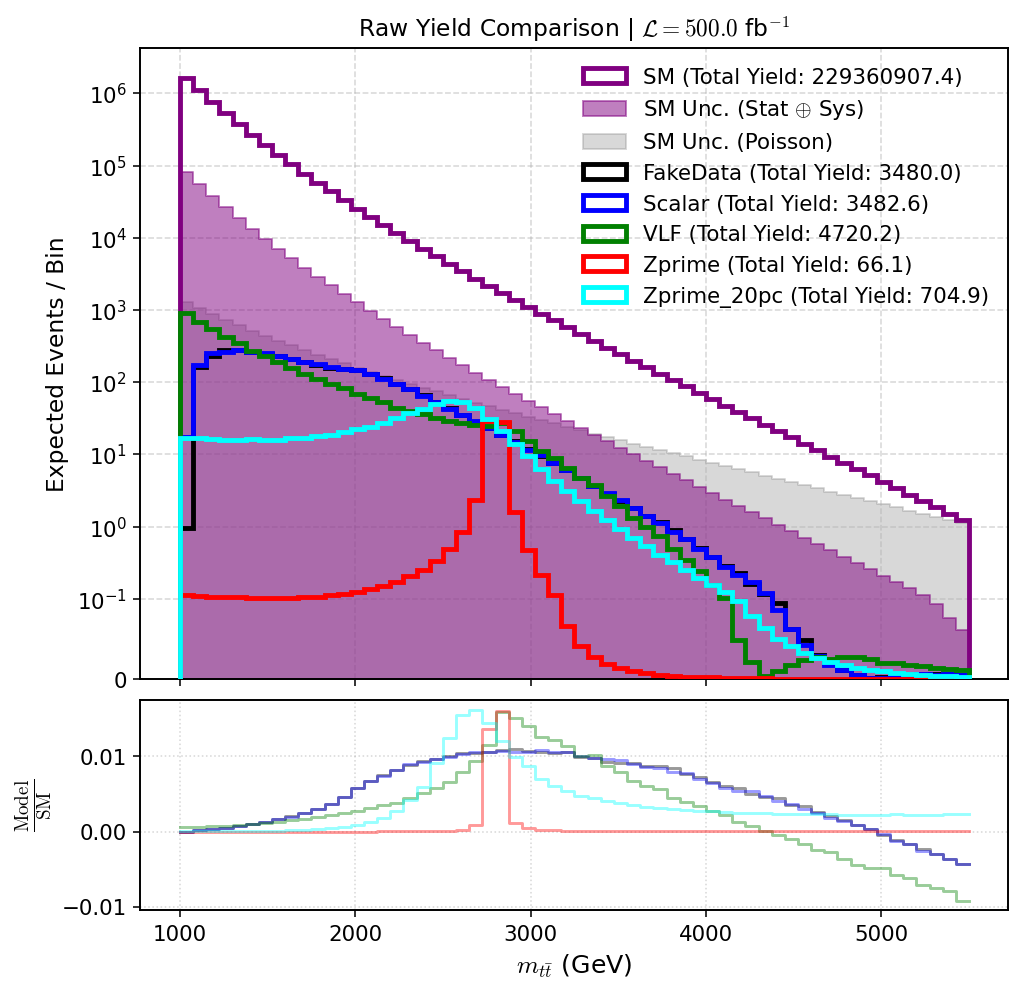

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.05):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # 1. Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # 2. Extract and Bin SM (Calculating Sum of Squared Weights for Error)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    # Get yields and statistical variance
    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(h_sm)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'err_poisson': hErr_sm_poisson, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # 3. Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        if lab_str == 'FakeData':
            err = np.sqrt(np.abs(h))
        else:
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)

        # ============================================================
        # ONLY IN UPPER PANEL: SM Shaded Uncertainty Band
        # ============================================================
        if lab_str == 'SM':
            # Pad the arrays to match the length of bin_edges for step='post'
            h_pad = np.append(data['h'], data['h'][-1])
            err_pad = np.append(data['err'], data['err'][-1])
            err_poisson_pad = np.append(data['err_poisson'], data['err_poisson'][-1])
            ax_main.fill_between(bin_edges,
                                 0,
                                 err_pad,
                                 step='post', color=c, alpha=0.5, zorder=2,
                                 label=r"SM Unc. (Stat $\oplus$ Sys)")
            ax_main.fill_between(bin_edges,
                                 0,
                                 err_poisson_pad,
                                 step='post', color='gray', alpha=0.3, zorder=1,
                                 label=r"SM Unc. (Poisson)")

            # Baseline for the ratio panel (no shading)
            #ax_ratio.axhline(1.0, color='k', linestyle='--', alpha=0.8, zorder=1)

        # Compute and plot the ratio to SM with Error Bars
        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            # Keep the faint step line connecting the points to match original aesthetic
            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=0.4, zorder=3)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [("m_tt", (1000, 5500))]
LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.05
    )

In [8]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]
mcuts = [ 300.0, 1000.,1500, 1800, 2000, 2200, 2500]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]

# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }

# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values,
                                fake_model='FakeData', sig_norm=False)

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1500, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)

df_lumi.to_csv('lumi_scan_results.csv', index=False)

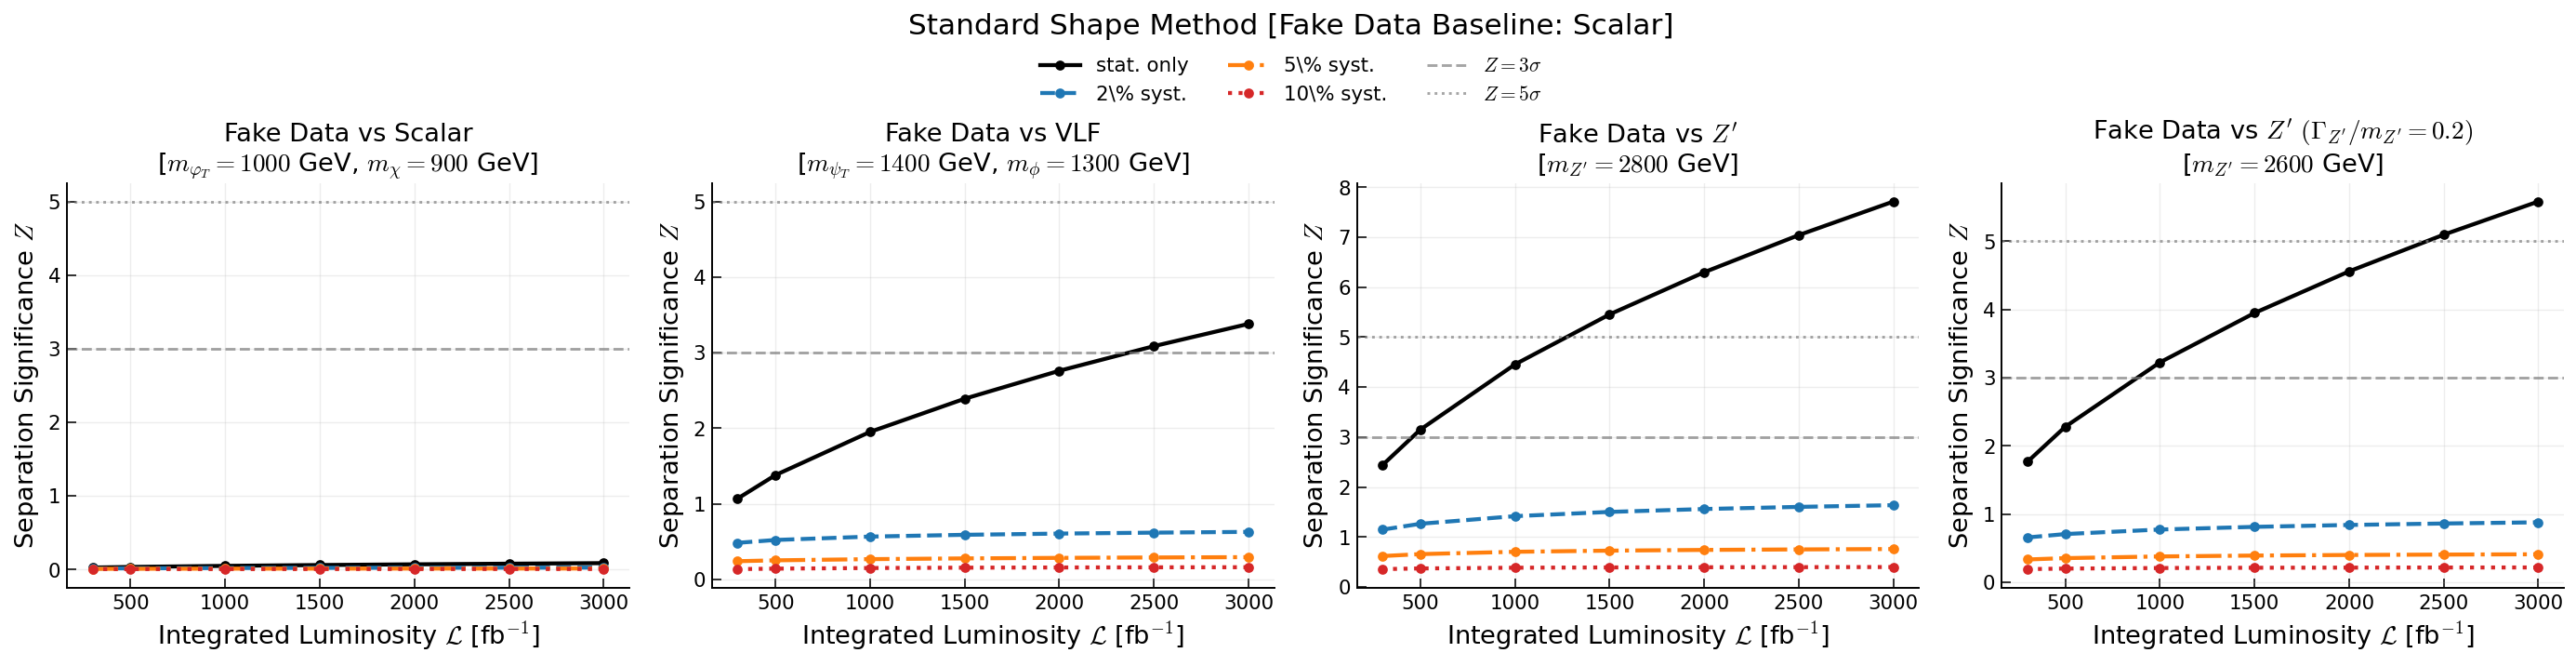

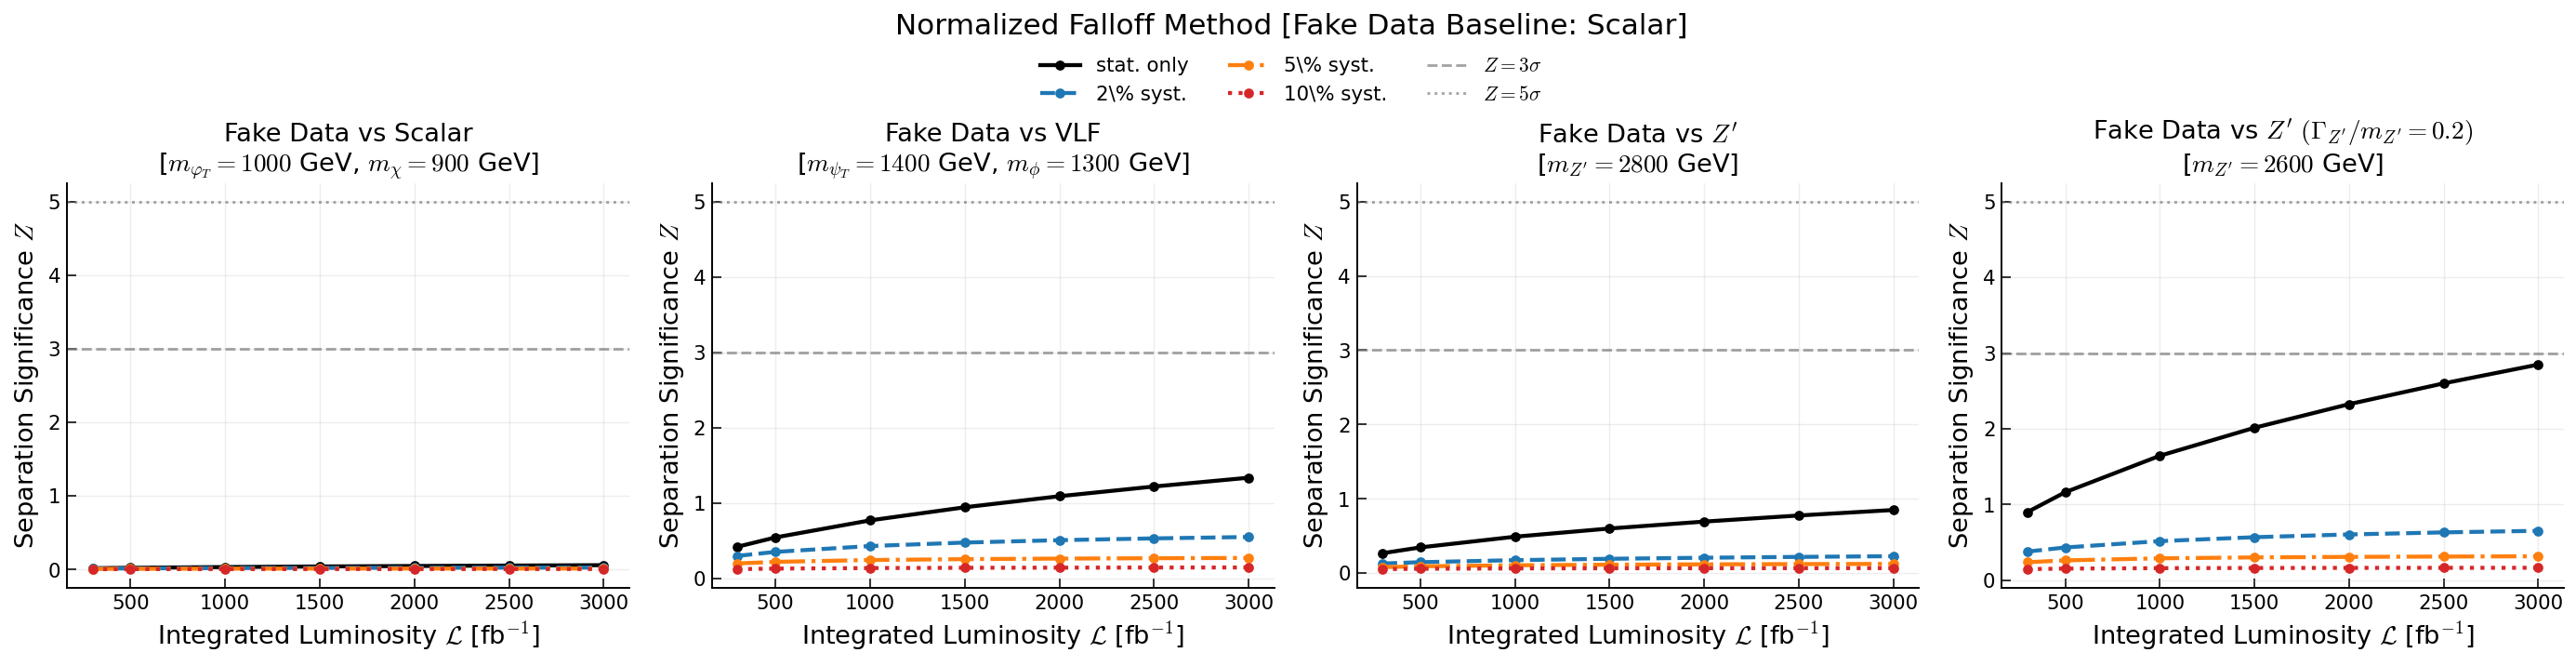

In [9]:
# Create output directory
outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)

#  Plot Mass Cut Scans
#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
 #                      outfile=outdir / "syst_grid_mcut_shape.pdf",
  #                     fake_model='Scalar', best_fits = best_fits)

#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
 #                      outfile=outdir / "syst_grid_mcut_falloff.pdf",
  #                     fake_model='Scalar', best_fits = best_fits)

# Plot Luminosity Scans
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf",
                       shareY = False, fake_model='Scalar', best_fits = best_fits)

hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_lumi_falloff.pdf",
                       shareY= False, fake_model='Scalar', best_fits = best_fits)


#hp.plot_ratio_pairwise(df_mcut, mcut_max, eps_values,
 #                      outfile=outdir / "improvement_ratio_mcut.pdf")

#hp.plot_ratio_pairwise_lumi(df_lumi, target_mcut=800, eps_values=eps_values,
 #                           outfile=outdir / "improvement_ratio_lumi.pdf")


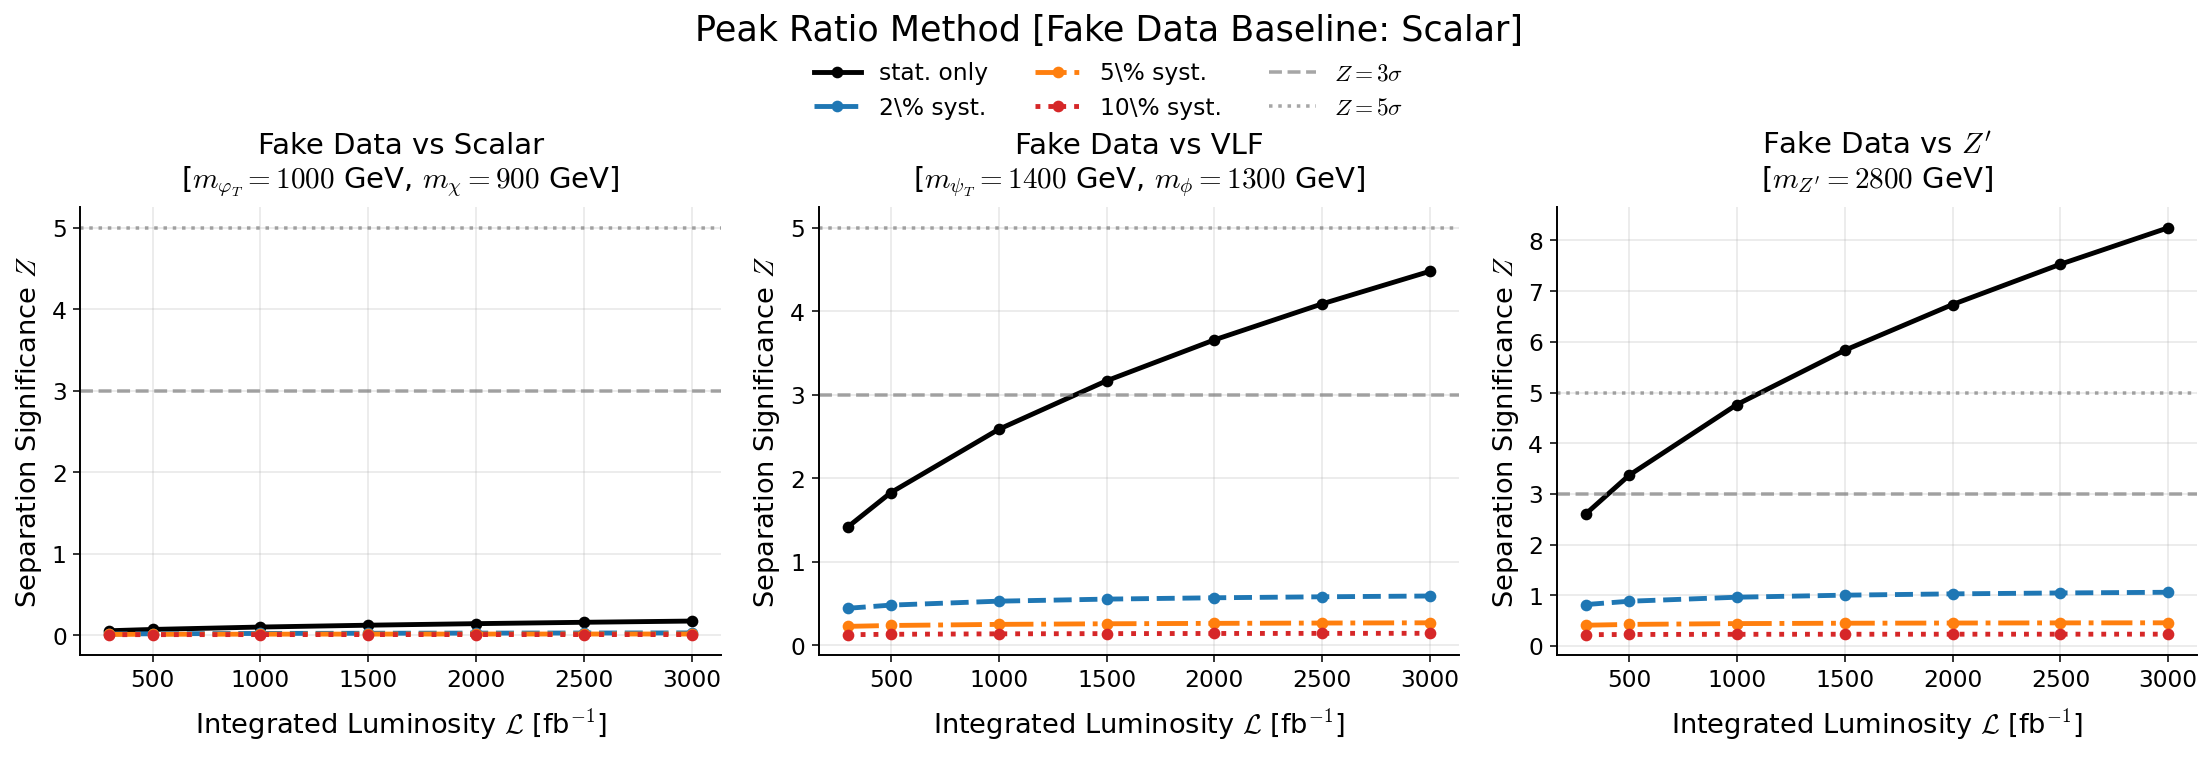

In [10]:

hp.plot_ratio_significance_vs_lumi(
    df_sm=df_sm,
    df_bsm=df_bsm,
    target_models=["Scalar", "VLF", "Zprime"],
    var="m_tt",
    lums=np.array([300, 500, 1000, 1500, 2000, 2500, 3000]),
    sys_err_list=[0.0, 0.02, 0.05, 0.10],
    rng=(800, 4500),
    peak_search_rng=(1500, 2500),
    asimov_model='FakeData',
    n_bp=18,
    n_ap=27,
    best_fits = best_fits
)

In [11]:
import helpers as hp
importlib.reload(hp)

<module 'helpers' from '/content/helpers.py'>

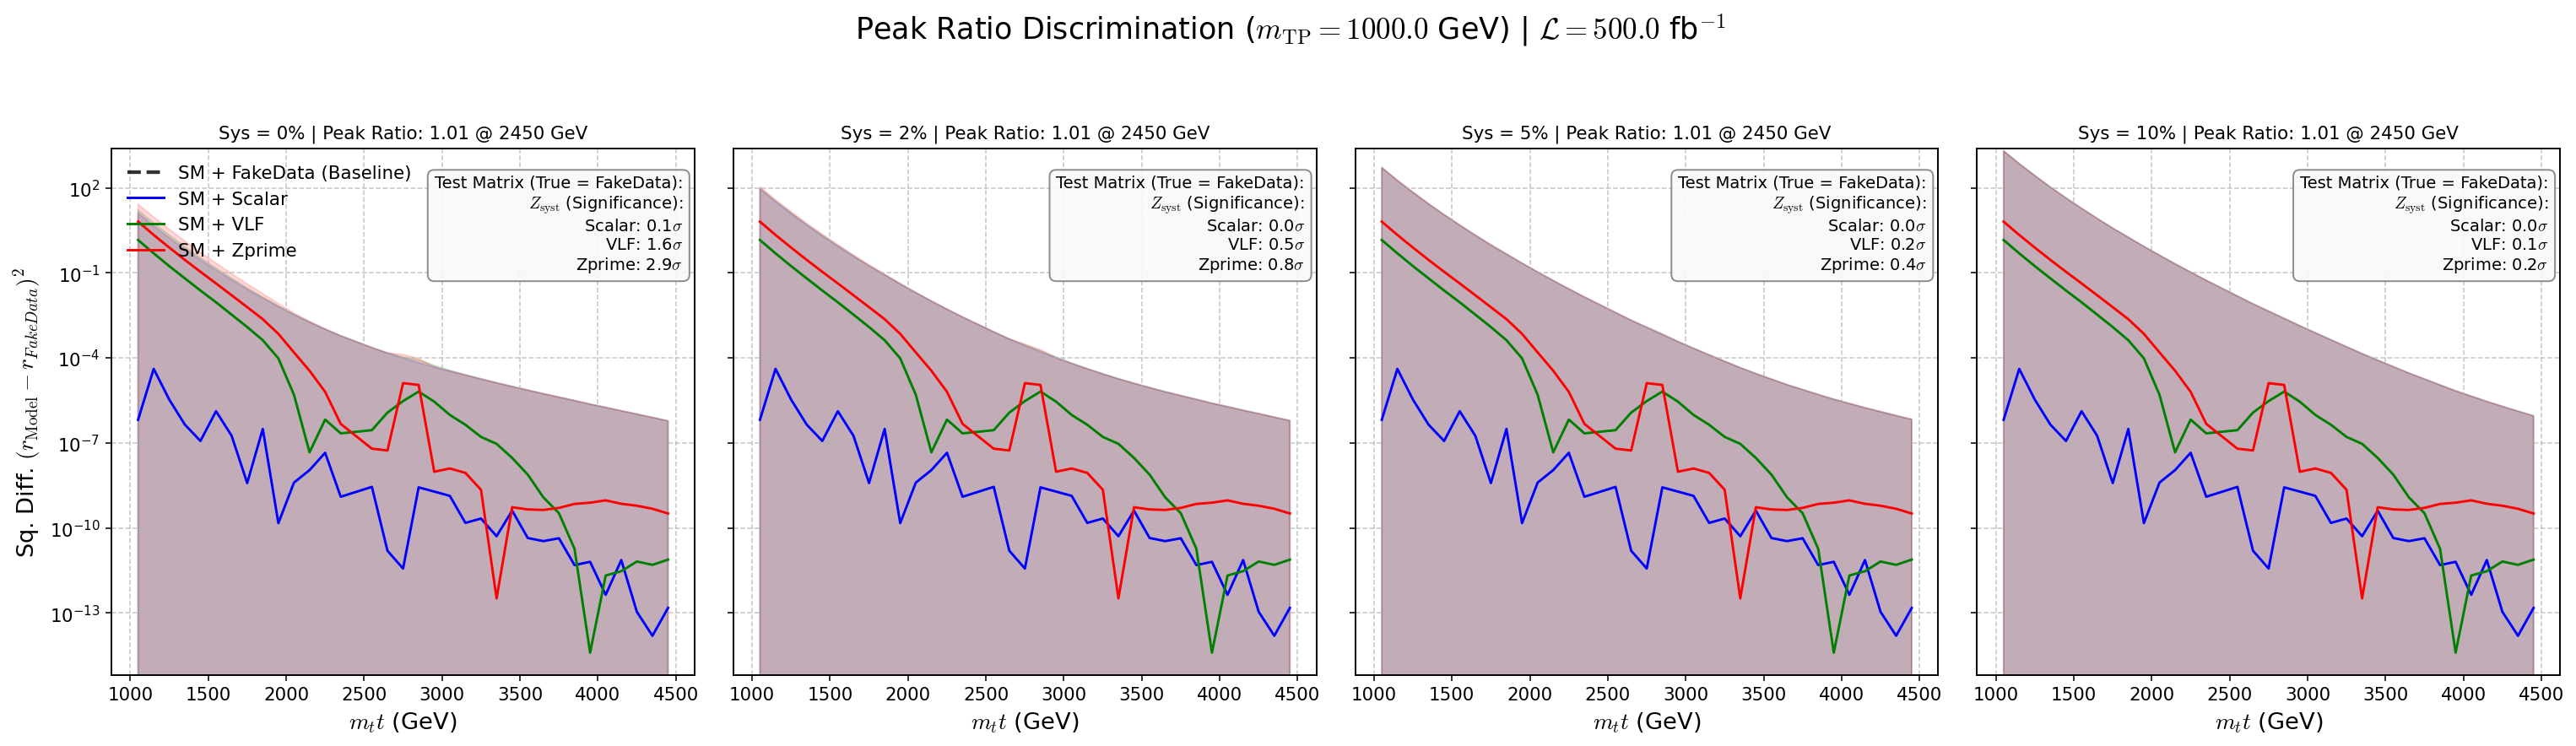


--- Significance Dictionary Exported ---
Saved successfully to: post_peak_ratios_significances.npz


In [12]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

def post_peak_ratio_sys_scan(df_sm, df_bsm, target_models=["FakeData", "Scalar", "VLF", "Zprime"],
                             var="m_tt", mTP=1000.0, lum=500.0,
                             bins=60, rng=(1500, 4500),
                             peak_search_rng=(1500, 2500),
                             asimov_model='FakeData',
                             n_bp=17, n_ap=26, sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
                             out_filename='post_peak_ratios_significances.npz'):
    """
    Scans over systematic uncertainties. Finds the peak dynamically via the max Data/SM ratio.
    Computes post-peak ratios, evaluates the Covariance Matrices, and plots the
    SQUARED absolute differences (Model - Baseline)^2 with robust second-order error bands.
    """
    def get_cols(df):
        l_col = "label" if "label" in df.columns else "model"
        w_col = "weight" if "weight" in df.columns else "w_norm"
        return l_col, w_col

    bin_edges = np.arange(rng[0], rng[1] + 100, 100)
    bin_centers_full = bin_edges[:-1] + np.diff(bin_edges)/2
    sys_q_dict = {}

    # ==========================================
    # 1. Extract Base Histograms
    # ==========================================
    lbl_sm, wgt_sm = get_cols(df_sm)
    df_sm_clean = df_sm[[lbl_sm, var, wgt_sm]].replace([np.inf, -np.inf], np.nan).dropna()
    x_sm = df_sm_clean[var].values
    w_sm = df_sm_clean[wgt_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm)
    var_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    lbl_bsm, wgt_bsm = get_cols(df_bsm)
    df_bsm_clean = df_bsm[[lbl_bsm, var, wgt_bsm]].replace([np.inf, -np.inf], np.nan).dropna()

    raw_signals = {}
    for sig in target_models:
        sig_df = df_bsm_clean[df_bsm_clean[lbl_bsm].astype(str) == sig]
        if not sig_df.empty:
            x_sig = sig_df[var].values
            w_sig = sig_df[wgt_bsm].values * lum * 1000.0
            h_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig)
            v_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig**2)
            raw_signals[sig] = {'h_sig': h_sig, 'v_sig': v_sig}

    if asimov_model not in raw_signals:
        raise ValueError(f"Asimov baseline model '{asimov_model}' not found in df_bsm.")

    model_significances = {}
    x_centers_dict = {}
    fig, axes = plt.subplots(1, len(sm_sys_err_list), figsize=(5.5 * len(sm_sys_err_list), 6), sharey=True)
    axes = np.atleast_1d(axes)

    # ==========================================
    # 2. Loop Over Systematic Errors
    # ==========================================
    for idx, sys_err in enumerate(sm_sys_err_list):
        ax = axes[idx]

        hypotheses = {}
        for sig, data in raw_signals.items():
            h_tot = h_sm + data['h_sig']
            err_tot = np.sqrt(var_sm + data['v_sig'] + (sys_err * h_sm)**2)
            hypotheses[sig] = {'h': h_tot, 'err': err_tot}

        h_asimov = hypotheses[asimov_model]['h']
        excess_ratio = np.divide(h_asimov, h_sm, out=np.zeros_like(h_asimov), where=h_sm > 0)

        range_mask = (bin_centers_full >= peak_search_rng[0]) & (bin_centers_full <= peak_search_rng[1])
        valid_mask = range_mask & (h_sm > 0)

        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) == 0:
             raise ValueError(f"No valid bins with SM > 0 found in the range {peak_search_rng}.")

        b_peak = valid_indices[np.argmax(excess_ratio[valid_indices])]

        start_idx = max(0, b_peak - n_bp)
        end_idx = min(len(bin_edges)-1, b_peak + n_ap)
        peak_local_idx = b_peak - start_idx
        x_centers = bin_centers_full[start_idx:end_idx]
        x_centers_dict[sys_err] = x_centers

        ratios_dict = {}
        for name, data in hypotheses.items():
            h, herr = data['h'], data['err']
            aux, err = [], []
            for j in range(start_idx, end_idx):
                A, B = h[j], h[b_peak]
                errA, errB = herr[j], herr[b_peak]
                val = A / B if B > 0 else 0
                aux.append(val)
                safe_err = val * np.sqrt((errA / A)**2 + (errB / B)**2) if (A > 0 and B > 0) else 0.0
                err.append(safe_err)
            ratios_dict[name] = {'r': np.array(aux), 'err': np.array(err)}

        r_A = ratios_dict[asimov_model]['r']
        stats_mask = np.arange(len(r_A)) != peak_local_idx
        valid_r_A = r_A[stats_mask]
        N_eval = len(valid_r_A)

        stats_lines = [
            rf"Test Matrix (True = {asimov_model}):",
            r"$Z_{\mathrm{syst}}$ (Significance):"
        ]
        q_dict = {}
        sym_err_dict = {}

        for name in hypotheses.keys():
            q_name_dict = {}
            if name == asimov_model:
                continue

            r_B = ratios_dict[name]['r'][stats_mask]

            n_B = hypotheses[name]['h'][start_idx:end_idx][stats_mask]
            n_peak_B = hypotheses[name]['h'][b_peak]

            n_ref = n_B
            n_peak_ref = n_peak_B
            r_ref = r_B

            C_ref = np.zeros((N_eval, N_eval))
            eps = sys_err

            peak_var_term = (1.0 + (eps**2) * n_peak_ref) / n_peak_ref if n_peak_ref > 0 else 0.0

            for i in range(N_eval):
                for j in range(N_eval):
                    if i == j:
                        bin_var_term = (1.0 + (eps**2) * n_ref[i]) / n_ref[i] if n_ref[i] > 0 else 0.0
                        C_ref[i, j] = (r_ref[i]**2) * (bin_var_term + peak_var_term)
                    else:
                        C_ref[i, j] = r_ref[i] * r_ref[j] * peak_var_term

            try:
                C_inv = np.linalg.inv(C_ref)
            except np.linalg.LinAlgError:
                C_inv = np.diag(1.0 / np.diag(C_ref))

            sym_err_dict[name] = np.sqrt(np.diag(C_ref))

            delta_r = valid_r_A - r_B
            q_name_dict['num'] = delta_r
            q_name_dict['denom'] = np.diag(np.diag(C_inv))
            q_name_dict['offd'] = C_inv - np.diag(np.diag(C_inv))

            q_A = delta_r.T @ C_inv @ delta_r
            Z_score = max(np.sqrt(q_A), 0.0)
            q_dict[name] = q_name_dict

            if name not in model_significances:
                model_significances[name] = {}
            model_significances[name][sys_err] = {
                'sqrt_chi2': Z_score,
                'z_score': Z_score
            }

            stats_lines.append(rf"{name}: {Z_score:.1f}$\sigma$")

        sys_q_dict[sys_err] = q_dict

        # ==========================================
        # 3. Fill Subplot (SQUARED Difference Format)
        # ==========================================
        colors = {'FakeData': 'black', 'Scalar': 'blue', 'VLF': 'green', 'Zprime': 'red'}

        r_base = ratios_dict[asimov_model]['r']

        # Initialize y limits. Since it's squared, the minimum will realistically be 0.
        y_min_plot, y_max_plot = 0.0, 0.0001

        for name in hypotheses.keys():
            lbl = f"SM + {name}"
            c = colors.get(name, 'magenta')

            if name == asimov_model:
                # Baseline is exactly 0 in a squared difference plot
                ax.axhline(0.0, color='k', linestyle='--', alpha=0.8, zorder=4, label=f"{lbl} (Baseline)")
            else:
                x_plot = x_centers[stats_mask]
                r_base_plot = r_base[stats_mask]
                r_model_plot = ratios_dict[name]['r'][stats_mask]

                # Step 1: Calculate raw difference
                raw_diff = r_model_plot - r_base_plot

                # Step 2: Calculate Squared Difference (Model - Baseline)^2
                y_val = raw_diff**2
                ax.plot(x_plot, y_val, label=lbl, color=c, markersize=4, linewidth=1.5, zorder=3)

                # Step 3: Propagate error robustly for Z = Y^2
                # Var(Z) = 4 * Y^2 * Var(Y) + 2 * (Var(Y))^2
                y_err = sym_err_dict[name]
                z_err = np.sqrt(4 * (raw_diff**2) * (y_err**2) + 2 * (y_err**4))

                ax.fill_between(x_plot, y_val - z_err, y_val + z_err, color=c, alpha=0.15, zorder=1)

                valid_y = y_val[np.isfinite(y_val)]
                if len(valid_y) > 0:
                    # We bound minimum at 0.0 to prevent scaling out of bounds since squares can't be negative
                    y_max_plot = max(y_max_plot, np.max(valid_y))

                valid_err_top = (y_val + z_err)[np.isfinite(z_err)]
                if len(valid_err_top) > 0:
                    y_max_plot = max(y_max_plot, np.max(valid_err_top))

        ax.set_xlabel(rf'${var}$ (GeV)', fontsize=14)
        ax.set_yscale('log')
        if idx == 0:
            ax.set_ylabel(rf'Sq. Diff. $(r_{{\mathrm{{Model}}}} - r_{{{asimov_model}}})^2$', fontsize=14)

        chosen_peak_mass = bin_centers_full[b_peak]
        max_ratio_val = excess_ratio[b_peak]
        ax.set_title(rf'Sys = {sys_err * 100:.0f}% | Peak Ratio: {max_ratio_val:.2f} @ {chosen_peak_mass:.0f} GeV', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.7)

        # Scale limits tightly. Negative y-limit is just padding for the zero line.
        y_range = y_max_plot
        ax.set_ylim(- (y_range * 0.05), y_max_plot + (y_range * 0.2))

        if idx == 0:
            ax.legend(fontsize=11, framealpha=1.0, loc='upper left')

        stats_text = "\n".join(stats_lines)
        ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

    # ==========================================
    # FINALIZATION
    # ==========================================
    fig.suptitle(rf'Peak Ratio Discrimination ($m_{{\mathrm{{TP}}}} = {mTP}$ GeV) | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$', fontsize=18, y=1.05)
    plt.tight_layout()
    plt.savefig('Squared_Difference_Curves_Sys_Scan.pdf', bbox_inches='tight')
    plt.show()

    print("\n--- Significance Dictionary Exported ---")
    np.savez(out_filename, results=model_significances)
    print(f"Saved successfully to: {out_filename}")

    return x_centers_dict, sys_q_dict
# ============================================================
# Execution Example
# ============================================================
x_centers, sys_q_dict = post_peak_ratio_sys_scan(
     df_sm=df_sm,
     df_bsm=df_bsm,
     target_models=["FakeData", "Scalar", "VLF", "Zprime"],
     var="m_tt",
     mTP=1000.0,
     lum=500.0,
     bins=60,
     rng=(1000, 4500),
     asimov_model='FakeData',
     n_bp=18,
     n_ap=27,
     sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
     out_filename='post_peak_ratios_significances.npz'
)

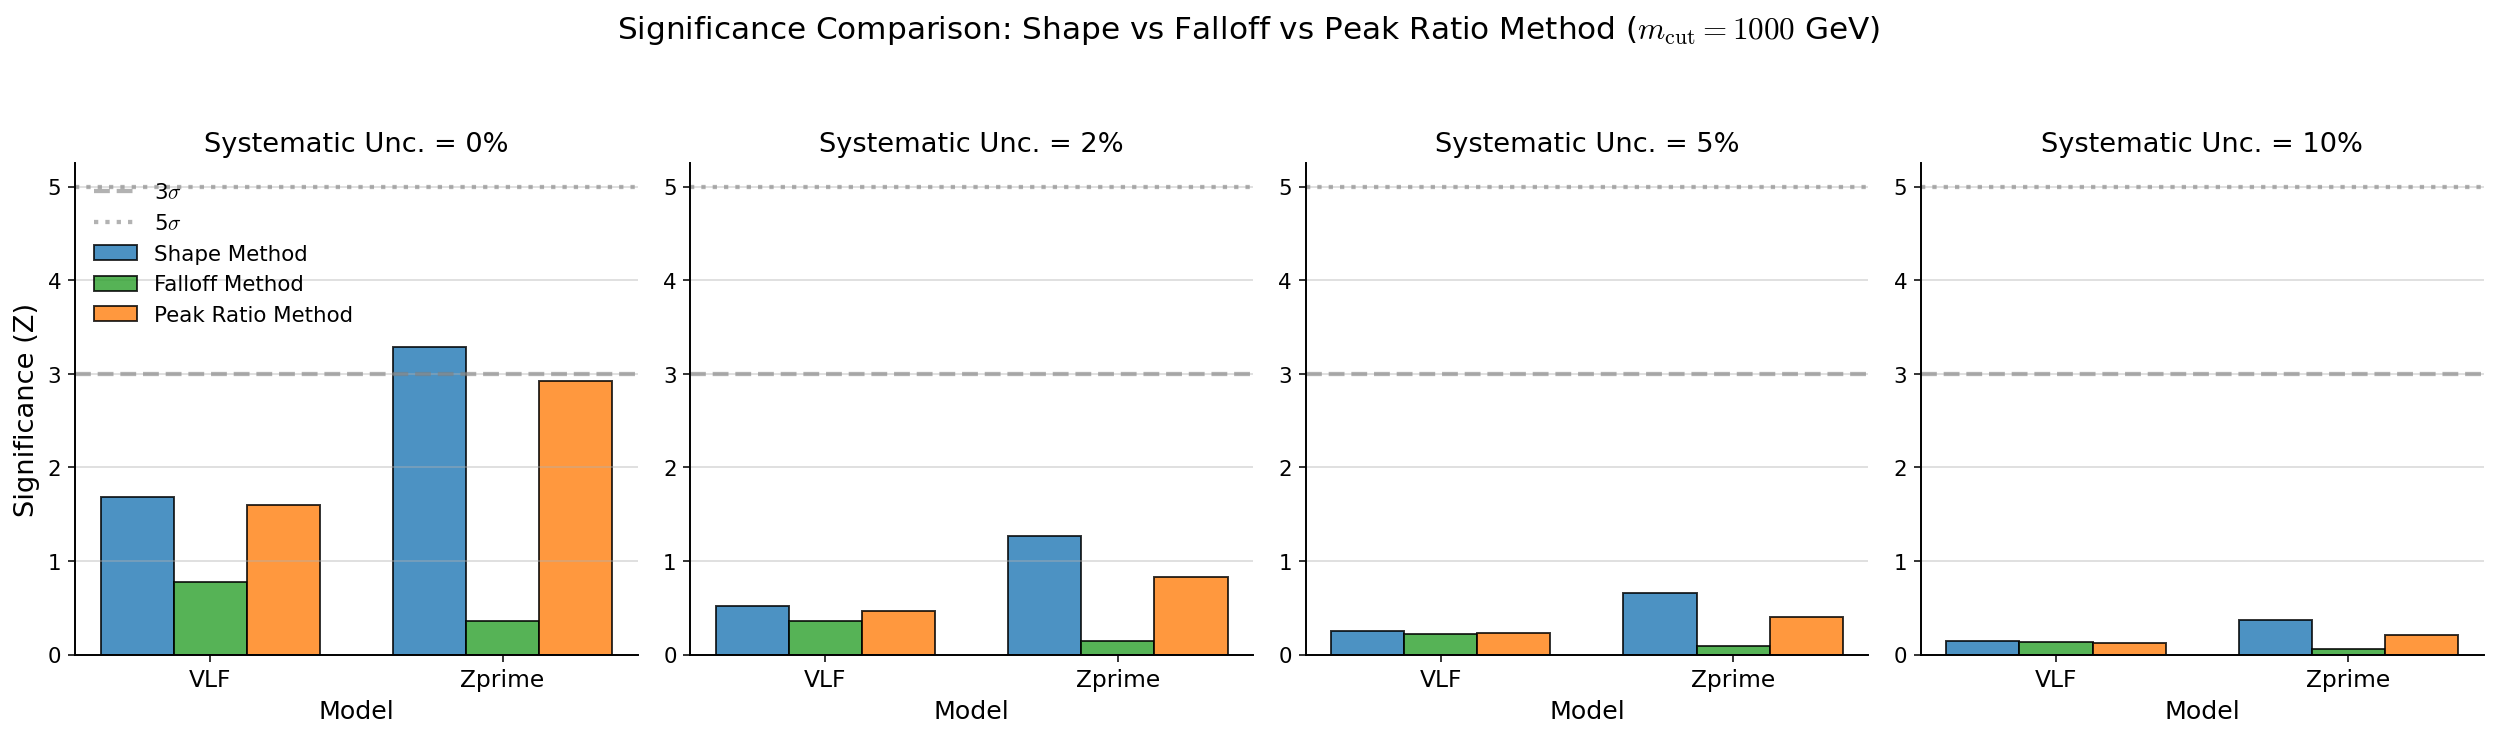

Results successfully compiled and saved to 'compiled_method_comparison.npy'


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Configuration & Data Loading
# -------------------------------------------------------------------
dict_path = './post_peak_ratios_significances.npz'

# Load the dictionary securely.
loaded_data = np.load(dict_path, allow_pickle=True)
if 'results' in loaded_data:
    post_peak_dict = loaded_data['results'].item()
else:
    post_peak_dict = {k: loaded_data[k].item() for k in loaded_data.files}

# Define the pairings and the X-axis labels
target_mcut = 1000

# Update to the new 'FakeData vs Model' naming convention used in df_mcut
pairs = ['FakeData vs VLF', 'FakeData vs Zprime']
x_labels = ['VLF', 'Zprime'] # The second name in the comparison
eps_values = [0.0, 0.02, 0.05, 0.10]

# -------------------------------------------------------------------
# Extract, Align, and Save the Data
# -------------------------------------------------------------------
df_sub = df_mcut[df_mcut['mcut'] == target_mcut]

shape_data = {eps: [] for eps in eps_values}
falloff_data = {eps: [] for eps in eps_values}
post_peak_data = {eps: [] for eps in eps_values}

# NEW: Initialize the master dictionary to save all extracted results
compiled_results = {model: {eps: {} for eps in eps_values} for model in x_labels}

for i, pair in enumerate(pairs):
    model = x_labels[i]
    row = df_sub[df_sub['pair'] == pair]

    # Match the model name (ignores spaces, cases, and underscores)
    matched_model_key = None
    clean_target = model.lower().replace(" ", "").replace("_", "")
    for k in post_peak_dict.keys():
        clean_k = str(k).lower().replace(" ", "").replace("_", "")
        if clean_target in clean_k:
            matched_model_key = k
            break

    if matched_model_key is None:
        print(f"WARNING: Could not find any match for model '{model}' in the dictionary!")

    for eps in eps_values:
        # Extract Shape Method Z-score
        col_name_sh = f"Z_sh_eps_{int(100*eps):02d}"
        if not row.empty and col_name_sh in row.columns:
            z_shape = row[col_name_sh].values[0]
        else:
            z_shape = 0.0
        shape_data[eps].append(z_shape)

        # Extract Falloff Method Z-score
        col_name_fa = f"Z_fa_eps_{int(100*eps):02d}"
        if not row.empty and col_name_fa in row.columns:
            z_falloff = row[col_name_fa].values[0]
        else:
            z_falloff = 0.0
        falloff_data[eps].append(z_falloff)

        # Extract Post-Peak sqrt(chi^2)
        val_post_peak = 0.0
        if matched_model_key is not None:
            model_dict = post_peak_dict[matched_model_key]
            for dict_eps, dict_vals in model_dict.items():
                if np.isclose(eps, dict_eps, atol=1e-5):
                    # Handle the nested dictionary structure
                    if isinstance(dict_vals, dict) and 'z_score' in dict_vals:
                        val_post_peak = dict_vals['z_score']
                    else:
                        print('Oh no')
                    break

        post_peak_data[eps].append(val_post_peak)

        # NEW: Save the specific values to the compiled dictionary
        compiled_results[model][eps] = {
            'Shape': z_shape,
            'Falloff': z_falloff,
            'PeakRatio': val_post_peak
        }

# -------------------------------------------------------------------
# Plotting the Comparison Grid
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 5), sharey=False)

x_indices = np.arange(len(x_labels))

# Narrow the bar width to fit 3 bars side-by-side
bar_width = 0.25

# Custom colors for the three methods
color_shape = '#1f77b4'      # Blue
color_falloff = '#2ca02c'    # Green
color_post_peak = '#ff7f0e'  # Orange

for i, eps in enumerate(eps_values):
    ax = axes[i]

    sh_vals = shape_data[eps]
    fa_vals = falloff_data[eps]
    pp_vals = post_peak_data[eps]

    # Plot grouped bars: offset by -bar_width, 0, and +bar_width
    ax.bar(x_indices - bar_width, sh_vals, bar_width, label='Shape Method', color=color_shape, edgecolor='black', alpha=0.8)
    ax.bar(x_indices, fa_vals, bar_width, label='Falloff Method', color=color_falloff, edgecolor='black', alpha=0.8)
    ax.bar(x_indices + bar_width, pp_vals, bar_width, label='Peak Ratio Method', color=color_post_peak, edgecolor='black', alpha=0.8)

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(f'Systematic Unc. = {int(eps*100)}%', fontsize=14)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_xlabel('Model', fontsize=13)

    # Draw reference lines for 3-sigma (evidence) and 5-sigma (discovery)
    ax.axhline(3.0, color='gray', linestyle='--', alpha=0.6, label=r'3$\sigma$')
    ax.axhline(5.0, color='gray', linestyle=':', alpha=0.6, label=r'5$\sigma$')

    if i == 0:
        ax.set_ylabel('Significance (Z)', fontsize=14)
        # Deduplicate legend handles (so 3/5 sigma lines only appear once)
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=False)

    ax.grid(axis='y', linestyle='-', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(rf'Significance Comparison: Shape vs Falloff vs Peak Ratio Method ($m_{{\mathrm{{cut}}}} = {target_mcut}$ GeV)', fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('Comparison_Shape_vs_Falloff_vs_PostPeak.pdf', bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------
# Export the Compiled Results
# -------------------------------------------------------------------
output_dict_name = 'compiled_method_comparison.npy'
np.save(output_dict_name, compiled_results)
print(f"Results successfully compiled and saved to '{output_dict_name}'")